In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
datapath=pd.read_csv("tit/titanic/gender_submission.csv")
dtest=pd.read_csv("tit/titanic/test.csv")
dtrain=pd.read_csv("tit/titanic/train.csv")
datapath.head()
dtest.head()
dtrain.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
dtest.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:

dtrain.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
women=dtrain.loc[dtrain.Sex=="female"]["Survived"]
avg=sum(women)/len(women)
print("Avg: %",avg)

Avg: % 0.7420382165605095


In [9]:
men=dtrain.loc[dtrain.Sex=="male"]["Survived"]
avg1=sum(men)/len(men)
print("Avg: %",avg1)

Avg: % 0.18890814558058924


In [11]:
from sklearn.ensemble import RandomForestClassifier
y=dtrain["Survived"]
features=["Pclass","Sex","SibSp","Parch"]	
X=pd.get_dummies(dtrain[features])
Xtest=pd.get_dummies(dtest[features])
model= RandomForestClassifier(n_estimators=100,max_depth=5,random_state=1)
model.fit(X,y)
predictions=model.predict(Xtest)
output = pd.DataFrame({'PassengerId': dtest.PassengerId, 'Survived': predictions})
output.head()



,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [12]:
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


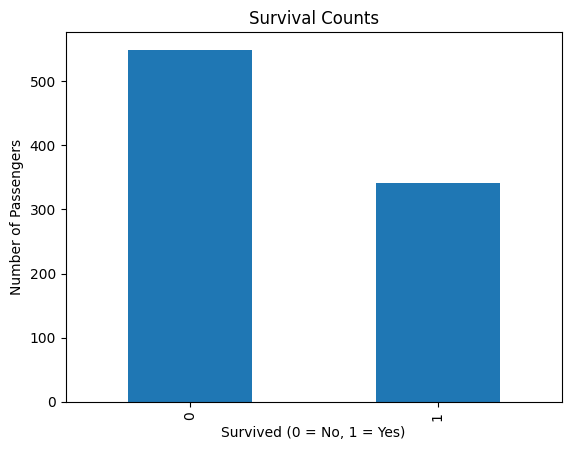

In [13]:
dtrain['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Counts") 
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

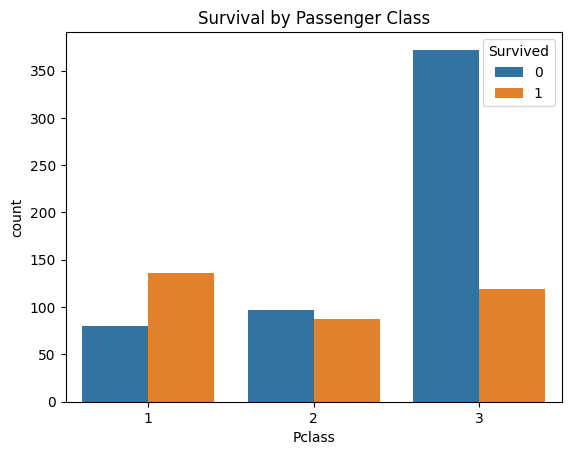

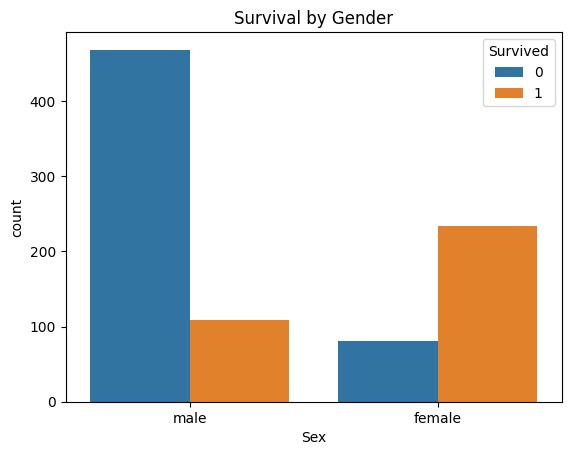

In [14]:
import seaborn as sns


sns.countplot(x='Pclass', hue='Survived', data=dtrain)
plt.title("Survival by Passenger Class")
plt.show()


sns.countplot(x='Sex', hue='Survived', data=dtrain)
plt.title("Survival by Gender")
plt.show()
